In [1]:
import os
import re
import sys
import yaml
import torch
sys.path.append('../../')
import numpy as np
import pandas as pd
import networkx as nx
from utils import utils
from utils.operation import *
from datetime import datetime
import matplotlib.pyplot as plt
from types import SimpleNamespace
from utils.metrics import select_metric

from Data.data_collect.Merge_collect import Merge_PygDataset
from Data.data_collect.datatype.excel.excel_collect import Excel_PygDataset
from Data.data_collect.datatype.spectrum.spe_collect import Spectrum_PygDataset
from Data.data_collect.datatype.knowledge_map.k_p_collect import Knowledge_graph_PygDataset

from task_data.graph.graph_construct import ConstructMolCls
from task_data.eval_data_construct import make_data,make_train_data,make_full_dm_list

from Models.LLM.LLM_Encoder import SentenceEncoder
from Models.models import PyGRGCNEdge,BinGraphModel,BinGraphAttModel


from Light.train import lightning_fit
from Light.data_module import DataModule
from Light.metric import flat_binary_func,EvalKit
from Light.template import ExpConfig,GraphPredLightning
from pytorch_lightning.loggers import WandbLogger

bin C:\Users\ljh\AppData\Roaming\Python\Python310\site-packages\bitsandbytes\libbitsandbytes_cuda116.dll


In [2]:
task_indicator = 2

# KG

In [3]:
# 加载知识图谱
Knowledge_graph_loader = Knowledge_graph_PygDataset()
FGD = Knowledge_graph_loader.data_loader('../../Datasets/Knowledge graph(chemistry)/knowledge_graph.gexf','graph')

In [4]:
# 加载振动信息
addition_information = Excel_PygDataset()
supplement_data = addition_information.data_loader('../../Datasets/Functional group (chemistry)/Functional_group_data_from_wiki_format.xlsx','text')
process_data = addition_information.preprocess()

In [5]:
# 图数据：FGD.data['1']['Data']
G = FGD.data['1']['Data'].copy()
# 给G添加复数节点：节点的名称为'Functional group{}';可能存在的振动节点；光谱范围节点
# 加入relation关系 ，has'range'
# {}为自然数列，从1开始，每个节点包含'raw_text'和'color'两个属性".
Append_node = []
Append_edge = []
for i in range(len(process_data)):
    # 检测该节点是否存在
    Subtype = ('#' + process_data.loc[i,'Subtype']).replace(' ','')
    core = ''

    dictionary_node = []
    dictionary_edge = []

    G.add_node(f'Range{i+1}',raw_text = process_data.iloc[i]['Range'],color = 'purple')
    dictionary_node.append(process_data.iloc[i]['Range'])
    G.add_node(f'S-Strength{i+1}',raw_text = process_data.iloc[i]['S-Strength'],color = 'yellow')
    dictionary_node.append(process_data.iloc[i]['S-Strength'])

    if process_data.iloc[i]['Functional group']!=None:
        core = ('#' + process_data.loc[i,'Functional group']).replace(' ','')
    else:
        core = Subtype
    if core not in G.nodes:
        G.add_node(core,raw_text = 'feature node. Functional group: <{}>.'.format(core),color = 'cyan')
    else:# 给节点core添加属性
        G.nodes[core]['raw_text'] = 'feature node. Functional group: <{}>.'.format(core)
        G.nodes[core]['color'] = 'cyan'
    if not G.has_edge(core,Subtype):
        G.add_edge(core,Subtype,relation='http://www.w3.org/1999/02/22-rdf-syntax-ns#type',id='2736')
            
    dictionary_node.append(core)

    if not G.has_edge(core,f'Range{i+1}'):
        G.add_edge(core,f'Range{i+1}',relation='feature edge.The absorption peak of this functional group cover the following range')
        dictionary_edge.append('FP-Ran')
    if not G.has_edge(f'Range{i+1}',f'S-Strength{i+1}'):
        G.add_edge(f'Range{i+1}',f'S-Strength{i+1}',relation='feature edge.The vibrational intensity of this absorption peak is as follows')
        dictionary_edge.append('Ran-Str')

    if process_data.iloc[i]['Absorb']!=None and process_data.iloc[i]['Absorb'] not in G.nodes:
        G.add_node(process_data.iloc[i]['Absorb'],raw_text = process_data.iloc[i]['Absorb'],color = 'yellow')
        dictionary_node.append(process_data.iloc[i]['Absorb'])
        if not G.has_edge(f'Range{i+1}',process_data.iloc[i]['Absorb']):
            G.add_edge(f'Range{i+1}',process_data.iloc[i]['Absorb'],relation='feature edge.The type of vibration of this absorption peak is as follows')
            dictionary_edge.append('Ran-Ab')
    elif process_data.iloc[i]['Absorb']!=None and process_data.iloc[i]['Absorb'] in G.nodes:
        dictionary_node.append(process_data.iloc[i]['Absorb'])
        if not G.has_edge(f'Range{i+1}',process_data.iloc[i]['Absorb']):
            G.add_edge(f'Range{i+1}',process_data.iloc[i]['Absorb'],relation='feature edge.The type of vibration of this absorption peak is as follows')
            dictionary_edge.append('Ran-Ab')
    
    Append_node.append(dictionary_node)
    Append_edge.append(dictionary_edge)

In [6]:
for i in range(len(process_data)):
    nx.relabel_nodes(G,{f'Range{i+1}':process_data.iloc[i]['Range']},copy=False)
FG_graph = G

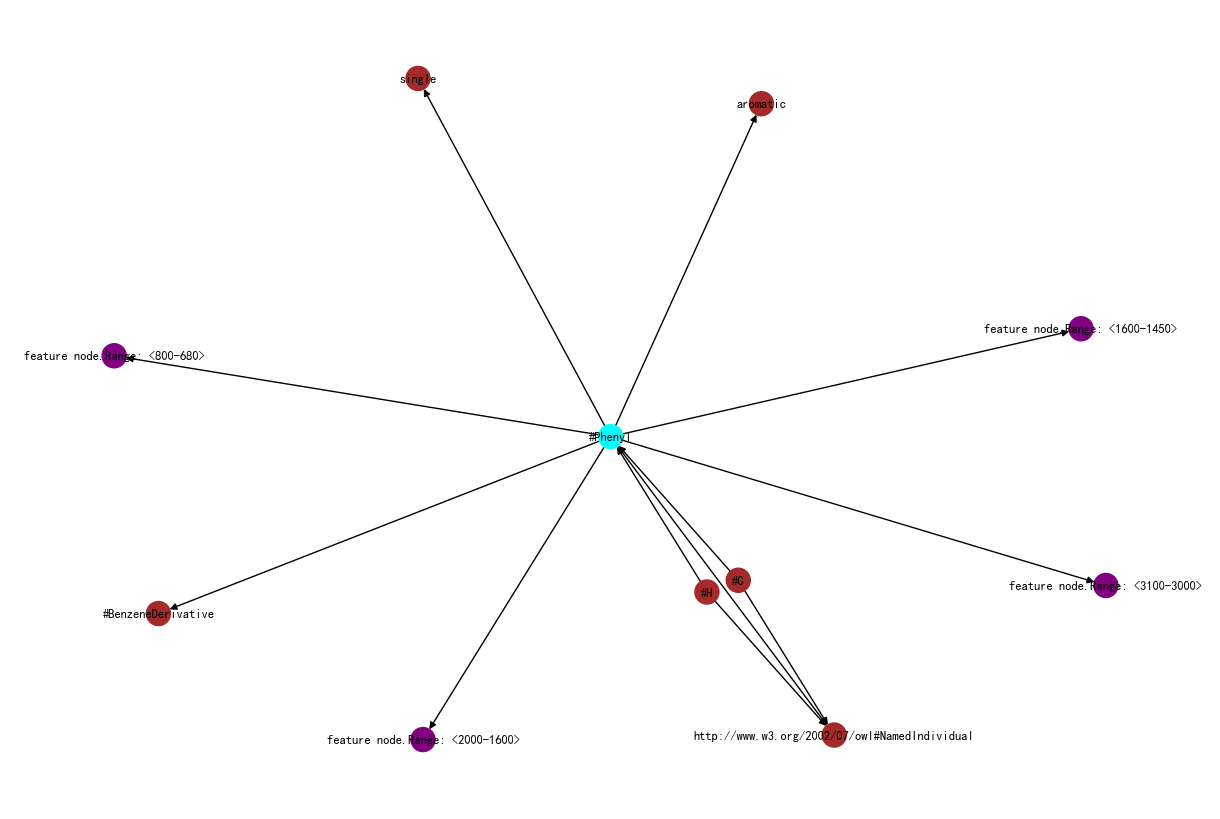

In [7]:
sub_graph = nx.generators.ego_graph(FG_graph, '#Phenyl', radius=1,undirected=True)
ppp = sub_graph

plt.rcParams['font.sans-serif'] = ['Simhei']  #显示中文
plt.rcParams['axes.unicode_minus'] = False    #显示负号
pos = nx.spring_layout(ppp)
#colors= [ppp.nodes[n]['color'] for n in ppp.nodes()]
colors = []
for n in ppp.nodes():
    try:colors.append(ppp.nodes[n]['color'])
    except:
        colors.append('brown')
        #print(n)

plt.figure(figsize=(12, 8))
nx.draw(ppp, pos=pos, with_labels=True,font_size=9,node_color=colors)
edge_labels = nx.get_edge_attributes(ppp, 'relatio')
nx.draw_networkx_edge_labels(ppp, pos=pos, edge_labels=edge_labels)
plt.show()

# Spec

In [8]:
# 加载光谱信息
Spectrum_loader = Spectrum_PygDataset()
SD = Spectrum_loader.data_loader('G:\Research\数据集\Pper4-Database\Spectral Database')
# SD里面有名字的相关储存

100%|██████████| 306/306 [00:02<00:00, 126.20it/s]


## Label

In [9]:
# Standed Format:
# Molecule:name - Combination:N - (Peak:m <Edge> Peak:n) - Label:0
# Label_data = {'Molecule':[],'Combination':[],'Peak':[],'Label':[],
#                node_index:[a,b],
#}

In [10]:
spectrum_dataset = Spectrum_loader.preprocess(SD.data)

In [11]:
# 补充数据掩膜与标签,在此仅做占位
label = pd.read_excel(r'G:\Research\数据集\Pper4-Database\spect-分子式+学名_语义编码.xlsx')

Meta_Data = {}
for i in range(len(label)):
    meta_data = {}
    meta_data['label'] = label.iloc[i]['标签/双键结构，包括普通双键与芳香族']
    
    Meta_Data[label.iloc[i]['Molecular formula']] = meta_data
Meta_Data = utils.make_mask_proportion(Meta_Data)

In [12]:
Spectrum_graph = Spectrum_loader.construct_graph(spectrum_dataset,kwargs=Meta_Data)

In [13]:
#Spectrum_loader.graph_visualisation(Spectrum_graph['(C6H4)2']['graph'])

# Save

In [39]:
import pickle
# # 保存Spectrum_graph文件
with open(f'../../Datasets/Data_for_different_task/Task{task_indicator}/Small_Molecules/Spectrum_graph.pkl', 'wb') as f:
    pickle.dump(Spectrum_graph, f)
# # 保存FG_graph文件
with open(f'../../Datasets/Data_for_different_task/Task{task_indicator}/Small_Molecules/FG_graph.pkl', 'wb') as f:
    pickle.dump(FG_graph, f)

# Merge(used for pyg)

In [15]:
test_class = Merge_PygDataset(FG_graph,Spectrum_graph['(C6H4)2'], Name = '(C6H4)2')
connected_dictionary = test_class.preprocess()
all_Table,isexist,score_dict = test_class.Negative_relevant_information(is_print=False)
OP = test_class.construct_graph(connected_dictionary,all_Table,is_print=False)
fin = test_class.subgraph_extraction(hop=2)

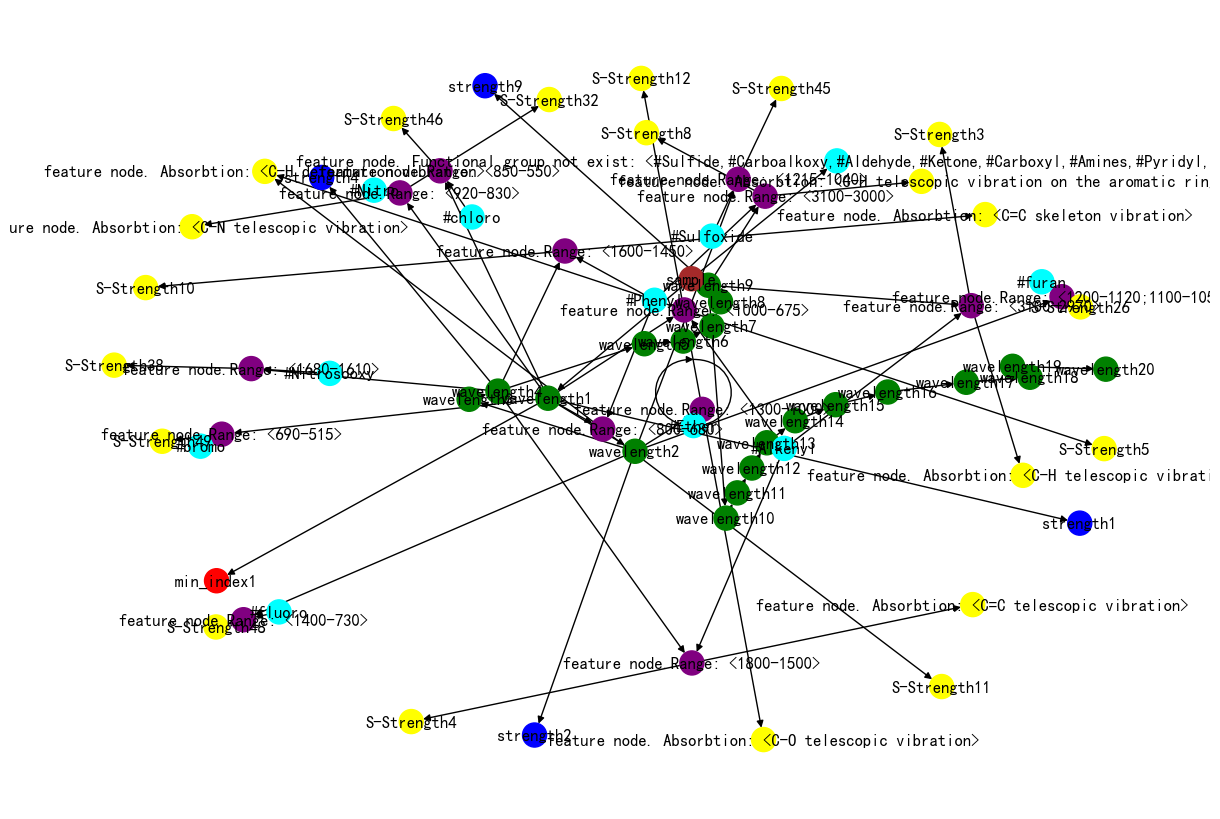

In [16]:
test_class.graph_visualisation(fin)

In [17]:
def get_related_fp_from_strength(node_list):
    strength_dict = {}
    for i in node_list:
        index = re.sub(u"([^\u0030-\u0039])","",i[0])
        link_fp = [i for i in OP.successors(f'wavelength{index}') if 'Range' in i]
        interval = []
        for j in link_fp:
            interval.append([k for k in OP.predecessors(j) if 'wave' not in k])
        interval = [k[0] for k in interval]
        strength_dict[i[0]] = interval
    return strength_dict

In [33]:
# 对于每一张图，扩充样本，举例：
# Step1: get strength node
pair_dict = {}
molecule_name = '(C6H4)2'
strength_node = [(node_name,attr) for node_name, attr in Spectrum_graph[molecule_name]['graph'].nodes(data=True) if 'strength' in node_name]
# 从strength_node中获取两两的分组
for i in range(len(strength_node)):
    for j in range(i+1,len(strength_node)):
        pair_dict[(strength_node[i][0],strength_node[j][0])] = (strength_node[i][1],strength_node[j][1])
pair_dict

# Step2: generate sample config
sample_list = []
for index,key in enumerate(pair_dict):
    sample_config = {'Molecule':molecule_name,'Combination_Index':index,'Peak':[key[0],key[1]],'Functional_Group':[],'Label':[],'node_index':[]}
    sample_list.append(sample_config)

# Step3: get the functional group associated with peak combination
strength_dict = get_related_fp_from_strength(strength_node)

# Step4: compare the peak pair and get the label of sample
for i in sample_list:
    for sub_peak in i['Peak']:
        i['Functional_Group'].append(strength_dict[sub_peak])
    # compare the two element in i['Functional_Group'] that wheather have same element
    # if have, then the label is 1, else the label is 0
    # write the code for me
    i['Label'] = 'Yes' if len(set(i['Functional_Group'][0]) & set(i['Functional_Group'][1]))>0 else 'No' 

# Step5: generate mask for all the sample in sample_list,the ratio should be 6:2:2 of train:valid:test



In [34]:
sample_list

[{'Molecule': '(C6H4)2',
  'Combination_Index': 0,
  'Peak': ['strength1', 'strength2'],
  'Functional_Group': [['#Phenyl', '#Alkenyl', '#bromo', '#chloro', '#Nitro'],
   ['#Sulfoxide', '#furan', '#fluoro', '#Ether']],
  'Label': 'No',
  'node_index': []},
 {'Molecule': '(C6H4)2',
  'Combination_Index': 1,
  'Peak': ['strength1', 'strength4'],
  'Functional_Group': [['#Phenyl', '#Alkenyl', '#bromo', '#chloro', '#Nitro'],
   ['#Nitrosooxy', '#Phenyl', '#Alkenyl']],
  'Label': 'Yes',
  'node_index': []},
 {'Molecule': '(C6H4)2',
  'Combination_Index': 2,
  'Peak': ['strength1', 'strength9'],
  'Functional_Group': [['#Phenyl', '#Alkenyl', '#bromo', '#chloro', '#Nitro'],
   ['#Alkenyl', '#Phenyl']],
  'Label': 'Yes',
  'node_index': []},
 {'Molecule': '(C6H4)2',
  'Combination_Index': 3,
  'Peak': ['strength2', 'strength4'],
  'Functional_Group': [['#Sulfoxide', '#furan', '#fluoro', '#Ether'],
   ['#Nitrosooxy', '#Phenyl', '#Alkenyl']],
  'Label': 'No',
  'node_index': []},
 {'Molecule': '

In [90]:
# point out
#[i for i in OP.successors('#Carboalkoxy')]
# point in 
#[i for i in OP.predecessors('#Carboalkoxy')]

#[i for i in OP.predecessors('#Carboalkoxy')]
#[i for i in OP.predecessors('feature node.Range: <1750-1670>')]    #  该官能团的该吸收范围不存在于光谱上
#[i for i in OP.predecessors('feature node.Range: <850-550>')]  #  该官能团的该吸收范围可能存在于光谱上

In [ ]:
# 1.遍历吸收峰并组合
# 2.获取标签

In [27]:
#test_class.graph_visualisation(fin)